# 04 · Evaluation (Train vs Test) and genre predictions for the 400 unknown shows

**Target:** Accuracy, Sensitivity, Specificity, Precision, F1 ≥ 0.89 on Train and Test (support-weighted one-vs-rest); Train-Test accuracy gap ≤ 0.05. Macro averages and per-genre values are secondary.

Two evaluation designs:
* **Holdout:** Train = 480-show training split, Test = the 120 held-out shows.
* **Repeated CV:** 5 × 5-fold on all 600 shows, hyperparameters fixed. Train = in-fold fit, Test = out-of-fold predictions. Each repeat tests all 600 shows, so this estimate is about 2.5 times more precise than the 120-show holdout.

In [1]:
# --- Setup: make the project package importable from notebooks/ -------------
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 170)

from src import config as cfg
print("Project root:", ROOT)

Project root: /home/claude/tv-genre-classification


In [2]:
# Rebuild the cleaned data if it is missing (fresh clone)
from src.data import make_dataset
if not cfg.TRAIN_FILE.exists():
    make_dataset.main()
# Train once if the saved models are missing (about 2 minutes)
if not all(cfg.model_file(m, "production").exists() for m in cfg.MODEL_NAMES):
    from src.features import build_features as bf
    from src.models import train_model as tm
    bf.run(); tm.run(); plt.close("all")
elif not cfg.SELECTED_FEATURES_FILE.exists():
    from src.features import build_features as bf
    bf.run(); plt.close("all")
from src.models import evaluate_model as em, train_model as tm
from src.data.make_dataset import get_xy, load
from src.utils import load_json
feats = load_json(cfg.MODEL_METADATA_FILE)["features"]
models = tm.load_models("evaluation", include_screened=True)
sets = {"Train": get_xy(load("train"), feats), "Test": get_xy(load("holdout"), feats)}
res, probs = em.evaluate(models, sets)
cv_res, folds = em.repeated_cv(models, *get_xy(load("labelled"), feats))
res.update(cv_res)
tab = em.comparison_table(res)

## 1. Train vs Test: repeated CV on 600 shows

In [3]:
display(Markdown(em.to_markdown(tab, ("CV Train", "CV Test"))))

| Metric | SSGMM CV Train | SSGMM CV Test | XGBoost CV Train | XGBoost CV Test | SVM-RBF CV Train | SVM-RBF CV Test |
|---|---:|---:|---:|---:|---:|---:|
| Accuracy | **0.907** | **0.904** | **0.921** | **0.901** | **0.911** | **0.903** |
| Sensitivity | **0.907** | **0.904** | **0.921** | **0.901** | **0.911** | **0.903** |
| Specificity | **0.908** | **0.907** | **0.910** | **0.900** | **0.903** | **0.902** |
| Precision | **0.906** | **0.902** | **0.921** | **0.899** | **0.911** | **0.902** |
| F1 | **0.905** | **0.902** | **0.919** | **0.898** | **0.908** | **0.900** |
| Sensitivity (macro) | 0.858 | 0.852 | 0.871 | 0.842 | 0.855 | 0.843 |
| Specificity (macro) | 0.938 | 0.937 | 0.944 | 0.934 | 0.938 | 0.935 |
| Precision (macro) | 0.894 | 0.888 | 0.922 | 0.889 | 0.909 | 0.892 |
| F1 (macro) | 0.874 | 0.869 | 0.893 | 0.862 | 0.878 | 0.864 |

## 2. Train vs Test: fixed 120-show holdout

In [4]:
display(Markdown(em.to_markdown(tab, ("Train", "Test"))))

| Metric | SSGMM Train | SSGMM Test | XGBoost Train | XGBoost Test | SVM-RBF Train | SVM-RBF Test |
|---|---:|---:|---:|---:|---:|---:|
| Accuracy | **0.917** | 0.858 | **0.933** | 0.875 | **0.917** | 0.883 |
| Sensitivity | **0.917** | 0.858 | **0.933** | 0.875 | **0.917** | 0.883 |
| Specificity | **0.919** | 0.867 | **0.928** | 0.861 | **0.913** | 0.862 |
| Precision | **0.915** | 0.852 | **0.933** | 0.872 | **0.916** | 0.883 |
| F1 | **0.915** | 0.852 | **0.932** | 0.868 | **0.915** | 0.875 |
| Sensitivity (macro) | 0.868 | 0.779 | 0.891 | 0.788 | 0.870 | 0.793 |
| Specificity (macro) | 0.945 | 0.909 | 0.954 | 0.912 | 0.943 | 0.915 |
| Precision (macro) | 0.905 | 0.825 | 0.931 | 0.864 | 0.911 | 0.883 |
| F1 (macro) | 0.885 | 0.798 | 0.909 | 0.818 | 0.888 | 0.826 |

In [5]:
display(Markdown("**Screened model (not deployed)**\n\n" + em.to_markdown(tab, ("Train", "Test", "CV Train", "CV Test"), models=cfg.SCREENED_MODELS, macro=False)))

**Screened model (not deployed)**

| Metric | DeepMLP Train | DeepMLP Test | DeepMLP CV Train | DeepMLP CV Test |
|---|---:|---:|---:|---:|
| Accuracy | **0.931** | 0.883 | **0.913** | **0.900** |
| Sensitivity | **0.931** | 0.883 | **0.914** | **0.900** |
| Specificity | **0.922** | 0.862 | **0.900** | **0.892** |
| Precision | **0.931** | 0.883 | **0.914** | **0.900** |
| F1 | **0.929** | 0.875 | **0.911** | **0.897** |

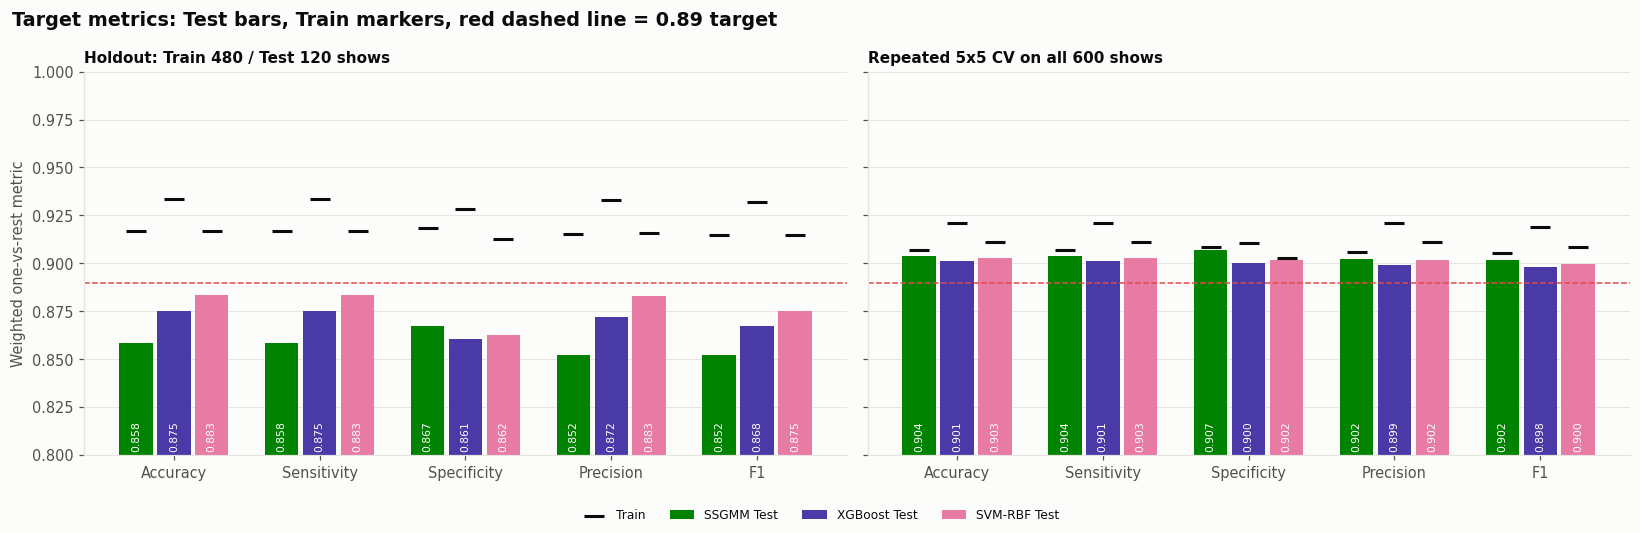

In [6]:
em.plot_metric_comparison(tab);

## 3. Acceptance

In [7]:
acc = em.acceptance(res)
display(acc.pivot_table(index=["Design", "Model"], values="Pass", aggfunc=["sum", "count"]))
acc[~acc.Pass].round(3)

sum count
                Pass  Pass
Design  Model             
CV      SSGMM     11    11
        SVM-RBF   11    11
        XGBoost   11    11
Holdout SSGMM      5    11
        SVM-RBF    6    11
        XGBoost    5    11

,Model,Design,Set,Criterion,Value,Rule,Pass
5,SSGMM,Holdout,Test,Accuracy,0.858,>= 0.89,False
6,SSGMM,Holdout,Test,Sensitivity,0.858,>= 0.89,False
7,SSGMM,Holdout,Test,Specificity,0.867,>= 0.89,False
8,SSGMM,Holdout,Test,Precision,0.852,>= 0.89,False
9,SSGMM,Holdout,Test,F1,0.852,>= 0.89,False
10,SSGMM,Holdout,Train - Test,Accuracy gap,0.058,<= 0.05,False
27,XGBoost,Holdout,Test,Accuracy,0.875,>= 0.89,False
28,XGBoost,Holdout,Test,Sensitivity,0.875,>= 0.89,False
29,XGBoost,Holdout,Test,Specificity,0.861,>= 0.89,False
30,XGBoost,Holdout,Test,Precision,0.872,>= 0.89,False


**Reading the results.**
* In **repeated CV** all three models meet the target on every metric, Train and Test (SSGMM Test ≈ 0.90 to 0.91; XGBoost and SVM-RBF ≈ 0.90), with Train-Test gaps of 0.003 to 0.02.
* On the **fixed 120-show holdout** the Test values are 0.85 to 0.88, below 0.89. This holdout is harder than average: even a mixture fitted on all 600 shows, holdout included, still misclassifies 14 of these 120 shows, and 6 of those 14 have P(label) ≈ 0 (likely mislabels). One show is worth 0.008 accuracy here, and the bootstrap 95% interval for SVM-RBF accuracy is about 0.83 to 0.94 (notebook 05).
* Weighted metrics meet the target; **macro** metrics do not (CV macro F1 ≈ 0.86 to 0.87), because Reality and Drama shows that look like Comedy are recalled less often. Macro is the right lens if each genre's campaign matters equally.

## 4. Per-genre metrics

,Model,Genre,Sensitivity,Specificity,Precision,NPV,F1,n,AUC
0,SSGMM,Comedy,0.959,0.809,0.886,0.927,0.921,73,0.905
1,SSGMM,Drama,0.808,0.957,0.840,0.947,0.824,26,0.892
2,SSGMM,Reality,0.571,0.960,0.750,0.913,0.649,21,0.818
3,XGBoost,Comedy,0.986,0.787,0.878,0.974,0.929,73,0.914
4,XGBoost,Drama,0.808,0.979,0.913,0.948,0.857,26,0.899
5,XGBoost,Reality,0.571,0.970,0.800,0.914,0.667,21,0.844
6,SVM-RBF,Comedy,1.000,0.787,0.880,1.000,0.936,73,0.909
7,SVM-RBF,Drama,0.808,0.979,0.913,0.948,0.857,26,0.896
8,SVM-RBF,Reality,0.571,0.980,0.857,0.915,0.686,21,0.821
9,DeepMLP,Comedy,1.000,0.787,0.880,1.000,0.936,73,0.900


,Model,Genre,Sensitivity,Specificity,Precision,NPV,F1,n,AUC
0,SSGMM,Comedy,0.973,0.865,0.919,0.953,0.945,367.0,0.945
1,SSGMM,Drama,0.824,0.975,0.897,0.954,0.859,127.0,0.940
2,SSGMM,Reality,0.760,0.971,0.849,0.950,0.802,106.0,0.917
3,XGBoost,Comedy,0.979,0.854,0.914,0.963,0.945,367.0,0.936
4,XGBoost,Drama,0.828,0.970,0.883,0.955,0.855,127.0,0.927
5,XGBoost,Reality,0.717,0.977,0.870,0.941,0.786,106.0,0.903
6,SVM-RBF,Comedy,0.981,0.856,0.915,0.967,0.947,367.0,0.936
7,SVM-RBF,Drama,0.831,0.970,0.880,0.955,0.855,127.0,0.929
8,SVM-RBF,Reality,0.717,0.979,0.882,0.942,0.791,106.0,0.893
9,DeepMLP,Comedy,0.981,0.838,0.905,0.966,0.942,367.0,0.939


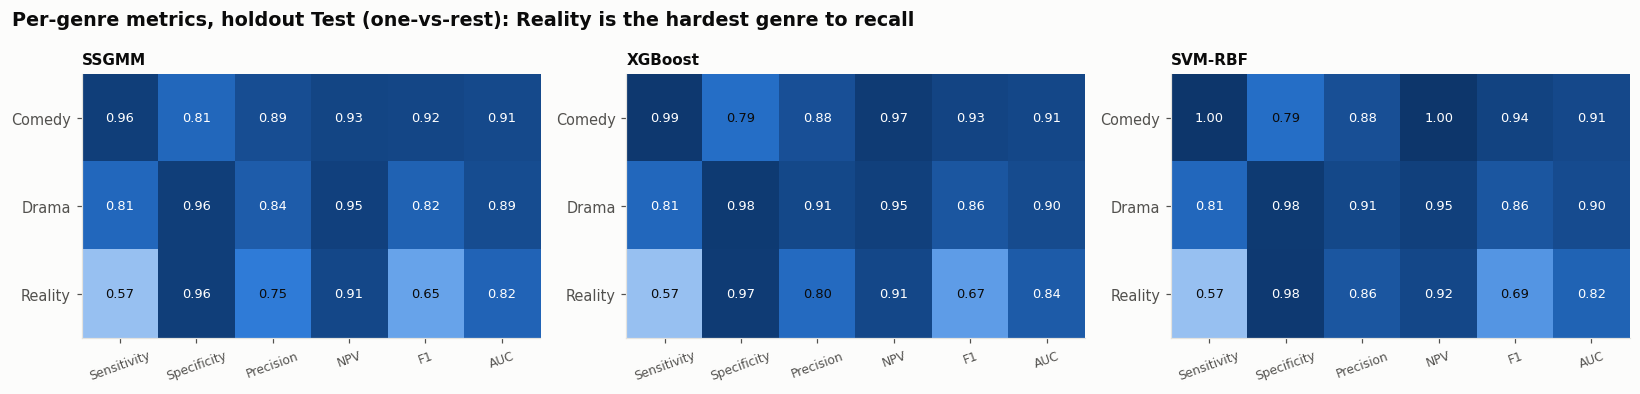

In [8]:
pc = em.per_class_table(res)
em.plot_per_class(pc)
display(pc.round(3))
em.per_class_table(res, "CV Test").round(3)

## 5. Diagnostics

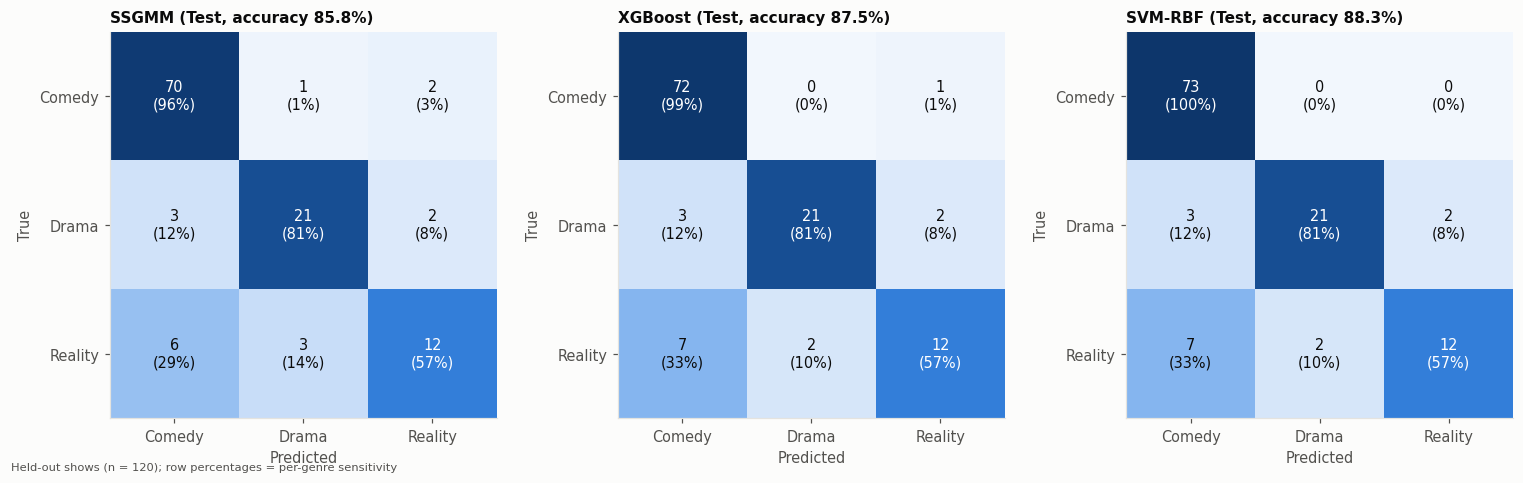

In [9]:
em.plot_confusion(res);

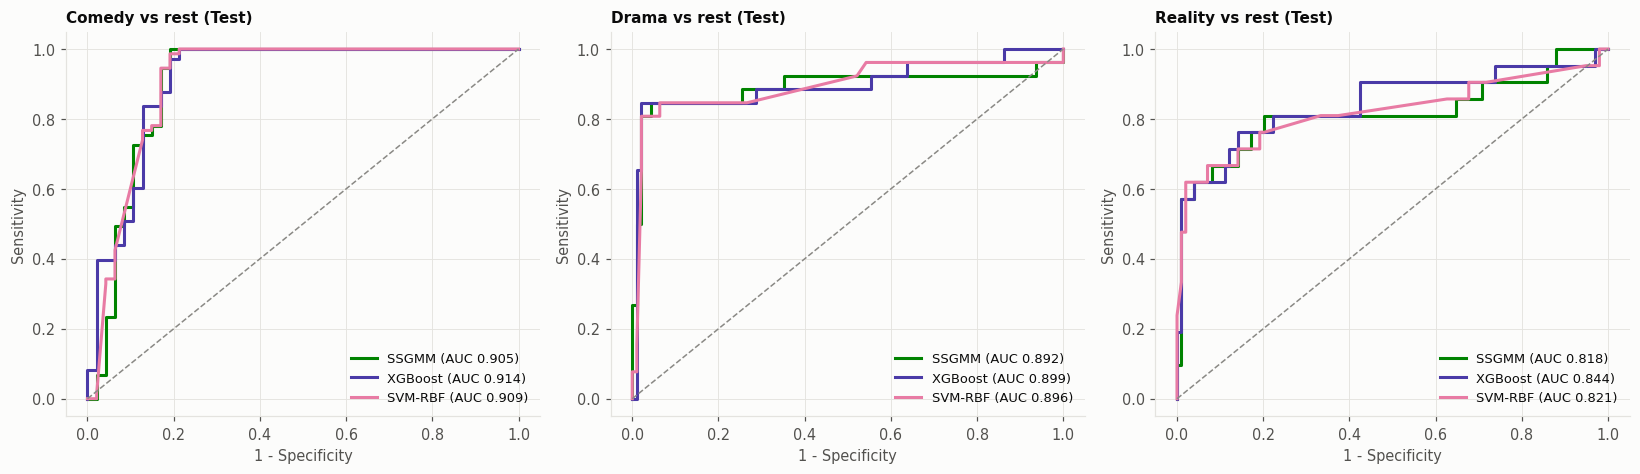

In [10]:
em.plot_roc(probs, sets);

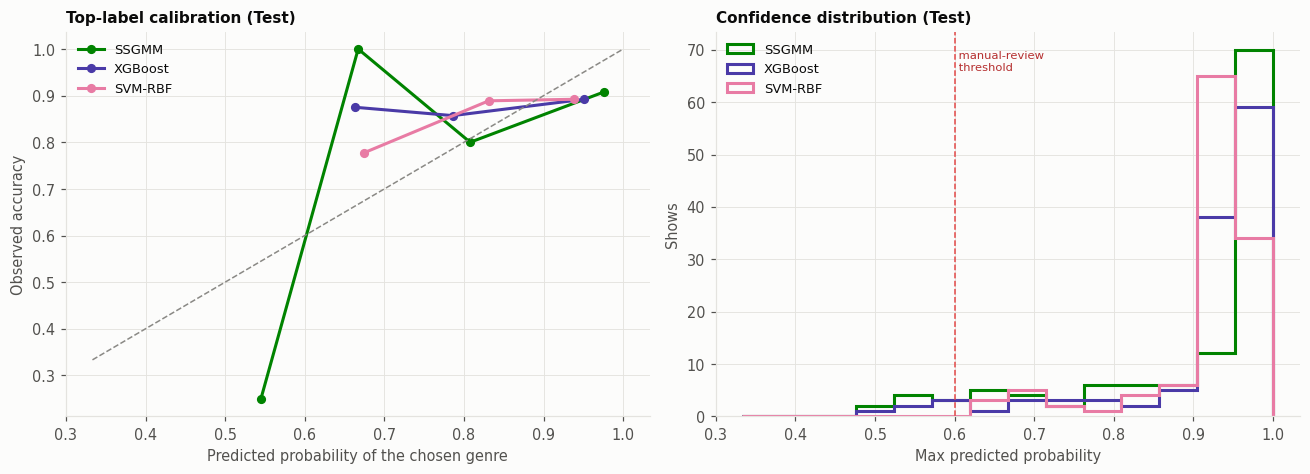

In [11]:
em.plot_calibration(probs, sets);

## 6. Feature importance

logP(Comedy)      0.238
logP(Drama)       0.183
logP(Reality)     0.175
comp Reality-1    0.101
comp Drama-1      0.034
comp Drama-2      0.033
comp Reality-2    0.032
I                 0.032
comp Comedy-2     0.032
N                 0.031
C                 0.027
L                 0.027
M                 0.027
comp Comedy-1     0.027
dtype: float64

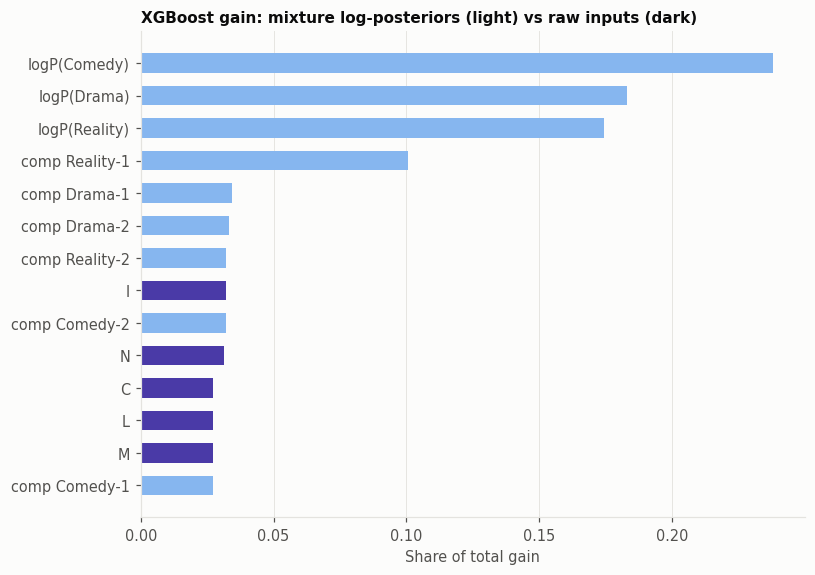

In [12]:
em.plot_xgb_gain(models["XGBoost"], feats).sort_values(ascending=False).round(3)

Model,SSGMM,SVM-RBF,XGBoost
feature,,,
C,0.3342,0.3525,0.3533
I,0.5346,0.5554,0.5462
L,0.3246,0.3375,0.3433
M,0.4467,0.4629,0.4683
N,0.5233,0.5408,0.5417


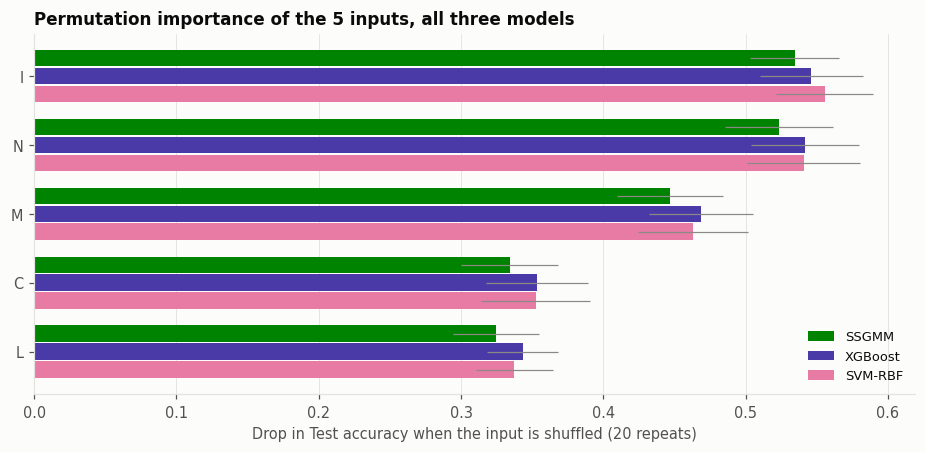

In [13]:
main = {k: v for k, v in models.items() if k in cfg.MODEL_NAMES}
perm = em.permutation_table(main, *sets["Test"])
em.plot_permutation(perm)
perm.pivot(index="feature", columns="Model", values="accuracy_drop_mean").round(4)

In [14]:
_ = em.run(); plt.close("all")      # write all evaluation tables and figures (as `make evaluate`)

13:24:40 | INFO    | src.models.evaluate_model | repeated 5x5 CV on all labelled shows


13:25:36 | INFO    | src.models.evaluate_model | Holdout:
| Metric | SSGMM Train | SSGMM Test | XGBoost Train | XGBoost Test | SVM-RBF Train | SVM-RBF Test |
|---|---:|---:|---:|---:|---:|---:|
| Accuracy | **0.917** | 0.858 | **0.933** | 0.875 | **0.917** | 0.883 |
| Sensitivity | **0.917** | 0.858 | **0.933** | 0.875 | **0.917** | 0.883 |
| Specificity | **0.919** | 0.867 | **0.928** | 0.861 | **0.913** | 0.862 |
| Precision | **0.915** | 0.852 | **0.933** | 0.872 | **0.916** | 0.883 |
| F1 | **0.915** | 0.852 | **0.932** | 0.868 | **0.915** | 0.875 |
| Sensitivity (macro) | 0.868 | 0.779 | 0.891 | 0.788 | 0.870 | 0.793 |
| Specificity (macro) | 0.945 | 0.909 | 0.954 | 0.912 | 0.943 | 0.915 |
| Precision (macro) | 0.905 | 0.825 | 0.931 | 0.864 | 0.911 | 0.883 |
| F1 (macro) | 0.885 | 0.798 | 0.909 | 0.818 | 0.888 | 0.826 |
CV:
| Metric | SSGMM CV Train | SSGMM CV Test | XGBoost CV Train | XGBoost CV Test | SVM-RBF CV Train | SVM-RBF CV Test |
|---|---:|---:|---:|---:|---:|---:|
| Acc

13:25:36 | INFO    | src.models.evaluate_model | Acceptance Holdout: 16/33 checks pass | per model {'SSGMM': False, 'SVM-RBF': False, 'XGBoost': False}


13:25:36 | INFO    | src.models.evaluate_model | Acceptance CV: 33/33 checks pass | per model {'SSGMM': True, 'SVM-RBF': True, 'XGBoost': True}


## 7. Classify the 400 shows of unknown genre
Production models (refit on all 600 labelled shows). Predicted genre = the recommended model (highest weakest-metric on the CV Test estimate); all three models' probabilities are kept; shows with confidence < 0.60 or model disagreement are flagged for review.

13:25:37 | INFO    | src.models.predict_model | Classified 400 shows -> {'Comedy': 271, 'Drama': 78, 'Reality': 51} | review 32 | agreement {'3/3': 389, '1/3': 6, '2/3': 5}


recommended model: SSGMM


,show_id,SSGMM_P_Comedy,SSGMM_P_Drama,SSGMM_P_Reality,Predicted_Genre,Confidence,Model_Agreement,Needs_Review
0,TE0000,0.9071,0.0631,0.0298,Comedy,0.9071,3/3,False
1,TE0001,0.8317,0.1655,0.0029,Comedy,0.8317,3/3,False
2,TE0002,0.7481,0.1091,0.1428,Comedy,0.7481,3/3,False
3,TE0003,0.0000,0.9983,0.0017,Drama,0.9983,3/3,False
4,TE0004,0.0000,0.0005,0.9994,Reality,0.9994,3/3,False
5,TE0005,0.6671,0.2795,0.0534,Comedy,0.6671,3/3,False
6,TE0006,0.0000,1.0000,0.0000,Drama,1.0000,3/3,False
7,TE0007,0.9842,0.0006,0.0152,Comedy,0.9842,3/3,False
8,TE0008,0.8944,0.0143,0.0913,Comedy,0.8944,3/3,False
9,TE0009,0.9130,0.0008,0.0862,Comedy,0.9130,3/3,False


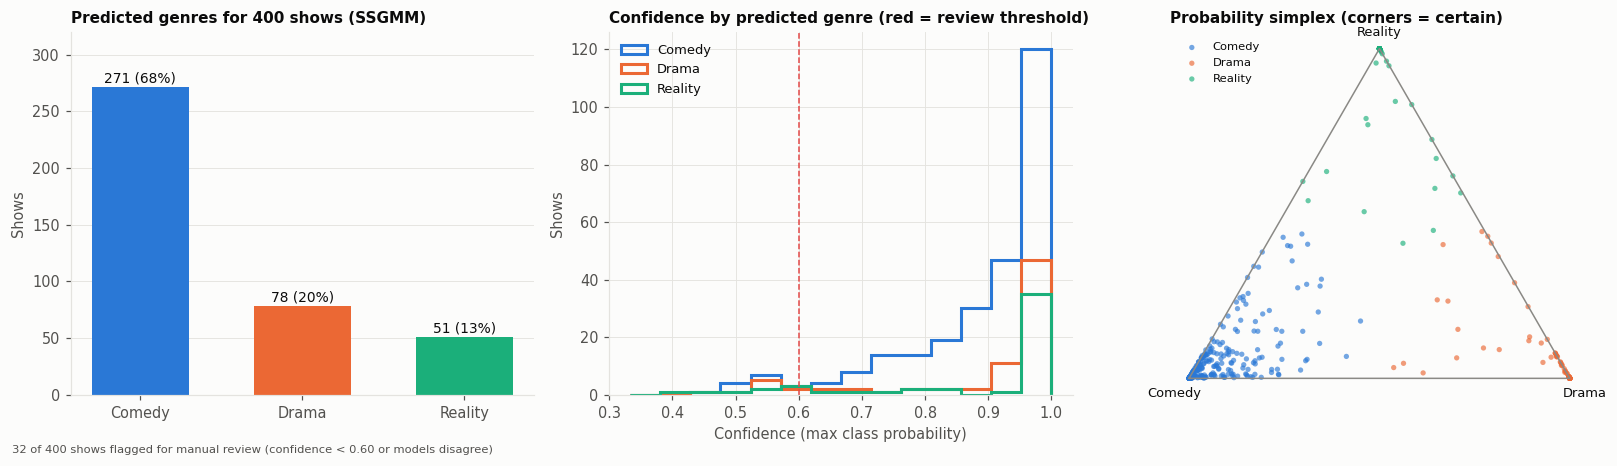

In [15]:
from src.models import predict_model as pm
pred = pm.main(); plt.close("all")
print("recommended model:", pm.RECOMMENDED)
pm.plot_predictions(pred)
rec = pm.RECOMMENDED.replace("-", "_")
cols = ["show_id"] + [f"{rec}_P_{c}" for c in cfg.CLASSES] + ["Predicted_Genre", "Confidence", "Model_Agreement", "Needs_Review"]
pred[cols].head(15)

In [16]:
pd.crosstab(pred.Predicted_Genre, pred.Needs_Review, margins=True)

Needs_Review,False,True,All
Predicted_Genre,,,
Comedy,258,13,271
Drama,68,10,78
Reality,42,9,51
All,368,32,400
